#  Exploratory Data Analysis (EDA) on Retail Sales Data

## Internship Project

**Internship:** Oasis Infobyte

**Task:** Task 1 – Exploratory Data Analysis on Retail Sales Data

**Name:** Anuja V S

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook

---

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify customer purchasing behavior, sales trends, product performance, and business insights using statistical analysis and data visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("retail_sales_dataset.csv", encoding="latin1")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## Dataset Preview

The first five rows of the dataset are displayed to verify that the dataset has been loaded successfully.

In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

Shape of Dataset: (1000, 9)

Column Names
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Types
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


## Observation

- The dataset contains customer demographic information and retail sales transactions.
- The data types and structure were inspected successfully.
- Missing values and duplicate records were checked before analysis.

In [8]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
df.mean(numeric_only=True)


Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [10]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [11]:
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


In [12]:
df.std(numeric_only=True)


Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

## Observation

The descriptive statistics summarize the distribution, central tendency, and variability of numerical columns such as Age, Quantity, Price per Unit, and Total Amount.

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

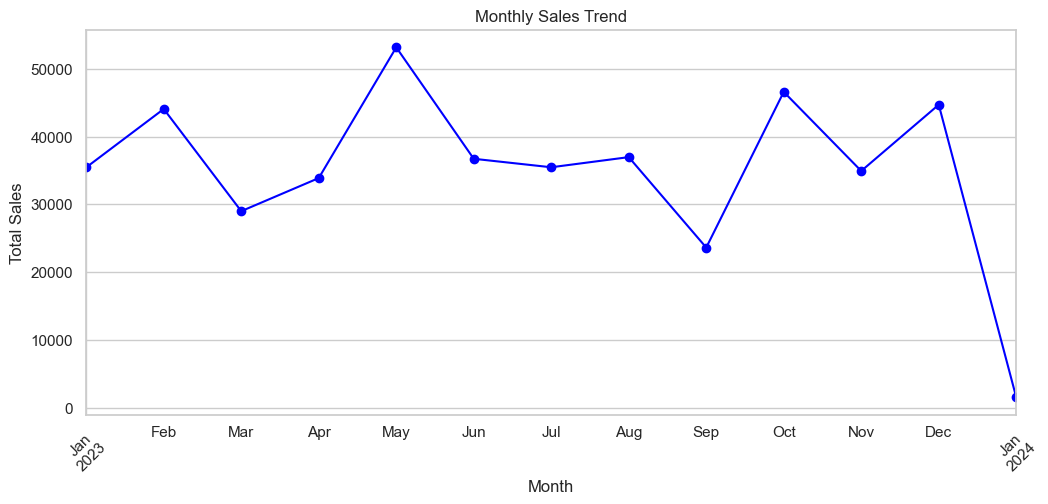

In [14]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o', color='blue')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## Observation

Monthly sales show fluctuations throughout the year, indicating seasonal purchasing behavior. Peak sales months can be targeted for promotional campaigns and inventory planning.

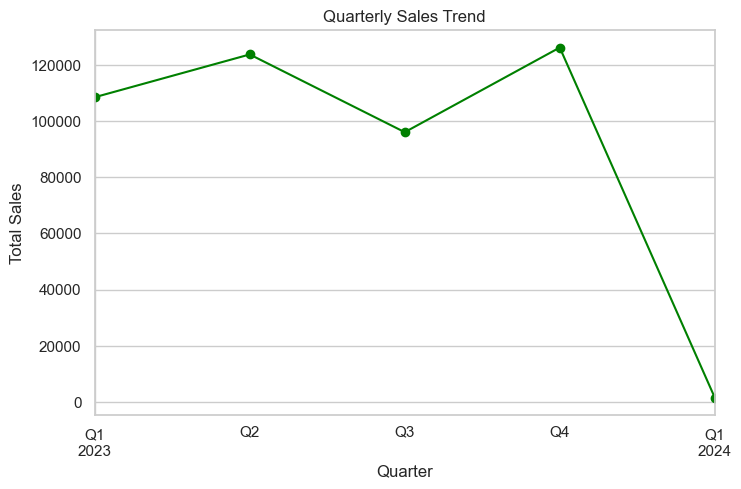

In [17]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(8,5))
quarterly_sales.plot(marker='o', color='green')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

## Observation

Quarterly sales analysis provides a broader understanding of business performance and helps identify long-term sales trends.

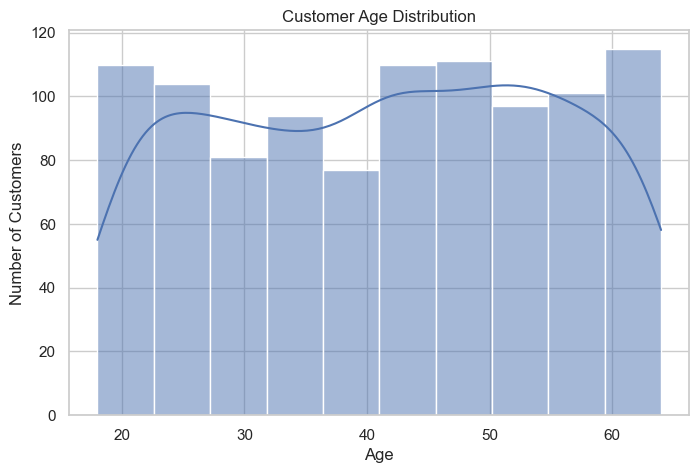

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

## Observation

The age distribution indicates that most customers belong to the middle-age group, suggesting that this segment contributes significantly to overall sales.

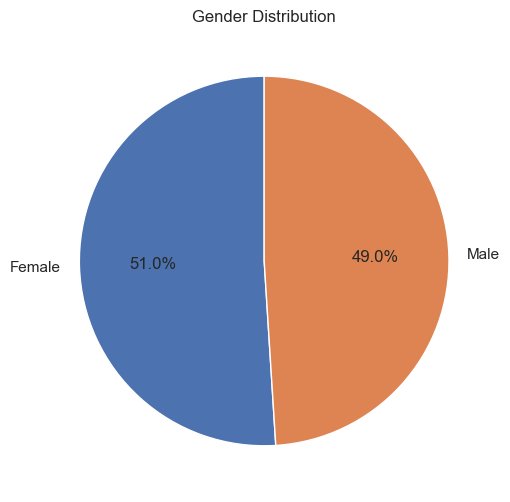

In [19]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.show()

## Observation

The gender distribution chart shows the proportion of male and female customers, providing insights into customer demographics.

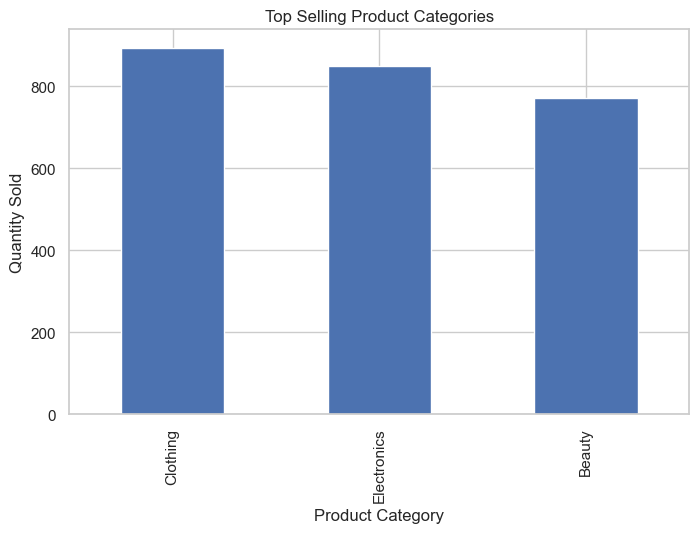

In [20]:
top_categories = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

top_categories.plot(kind='bar')

plt.title("Top Selling Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.show()

## Observation

Some product categories have significantly higher sales volumes than others. These categories should receive priority in inventory management and promotional campaigns.

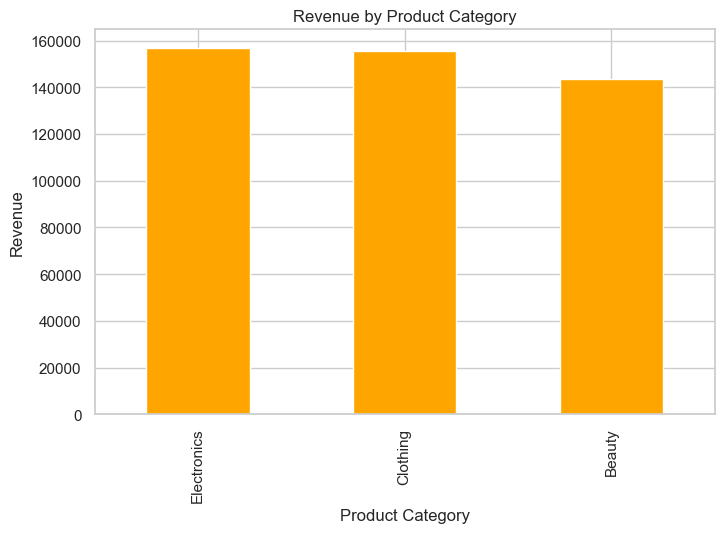

In [21]:
revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

revenue.plot(kind='bar', color='orange')

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

## Observation

Revenue varies across product categories. High-revenue categories contribute significantly to business profitability and should be prioritized for future growth.

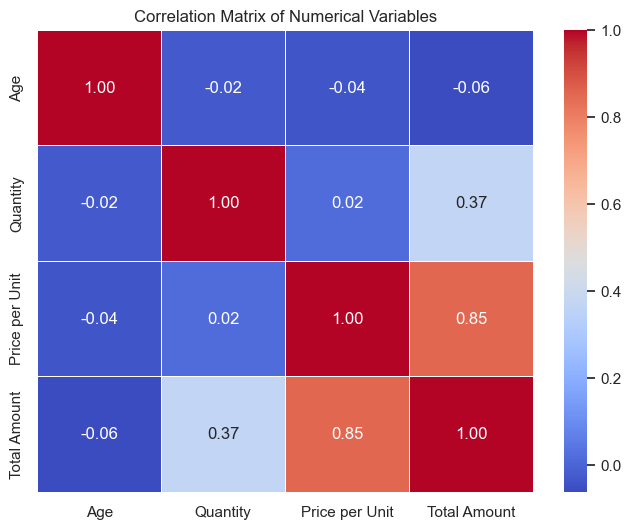

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Age','Quantity','Price per Unit','Total Amount']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

## Observation

The heatmap shows the strength and direction of relationships between numerical variables. Positive correlations indicate variables that tend to increase together, while weak correlations suggest little linear relationship.

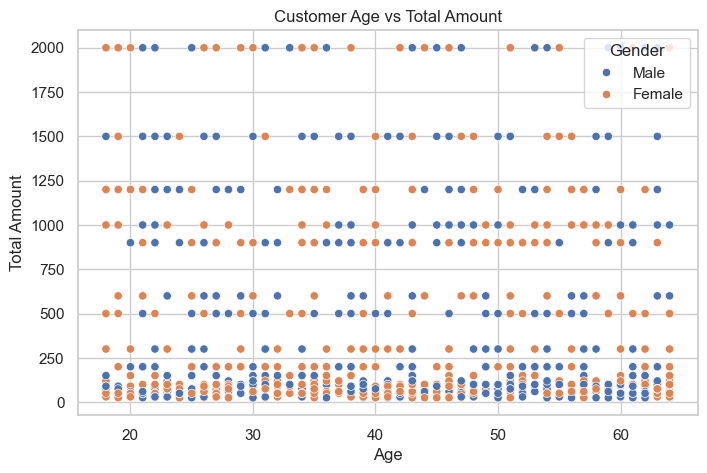

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Amount',
    hue='Gender'
)

plt.title("Customer Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")

plt.show()

## Observation

The scatter plot suggests how spending behavior changes with age and highlights any differences in purchasing patterns between male and female customers. This insight can help businesses design age-specific and gender-specific marketing campaigns.

# Conclusion

The Exploratory Data Analysis identified important patterns in customer demographics, sales performance, and product categories. These insights can support better decision-making and improve overall business performance.

## Business Recommendations

1. Increase inventory levels for top-selling product categories to avoid stock shortages.

2. Launch promotional campaigns during high-performing months to maximize sales and customer engagement.

3. Develop personalized marketing strategies based on customer age and gender to improve customer retention.

4. Focus on high-revenue product categories to increase profitability.

5. Monitor monthly and quarterly sales trends regularly to improve forecasting and inventory planning.

# Thank You

This project successfully demonstrates the use of Exploratory Data Analysis (EDA) techniques to analyze retail sales data. The findings can help businesses make informed decisions related to inventory management, customer segmentation, marketing strategies, and revenue optimization.